# **Projektowanie Leków -- Uczenie Maszynowe**

## Przygotowanie i importowanie pakietów

Wykonaj poniższe komórki, żeby zainstalować i zaimportować wszystkie potrzebne pakiety

In [1]:
!pip -qqq install torcheval torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 68.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torcheval.metrics import BinaryAccuracy
from torchmetrics.classification import BinaryConfusionMatrix

from sklearn.model_selection import train_test_split

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### **Zadanie 3.1**

Załaduj przygotowane wcześniej dane (w pliku csv) do obiektu klasy `DataFrame` o nazwie `data`

In [5]:
torch.manual_seed(42)
np.random.seed(42)

!wget https://raw.githubusercontent.com/kugi8412/DockGraph/CYP1A2/SelectGINE/CYP1A2/data/prepare_data.csv

data = pd.read_csv('prepare_data.csv')

--2026-02-01 09:35:17--  https://raw.githubusercontent.com/kugi8412/DockGraph/CYP1A2/SelectGINE/CYP1A2/data/prepare_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5706784 (5.4M) [text/plain]
Saving to: ‘prepare_data.csv’

prepare_data.csv    100%[===================>]   5.44M  --.-KB/s    in 0.02s   

2026-02-01 09:35:19 (245 MB/s) - ‘prepare_data.csv’ saved [5706784/5706784]



### **Zadanie 3.2**

Podziel `data` na `inputs` (porządane `features` do treningu)  i `labels`

In [6]:
inputs = data.drop(columns=['label'])
labels = data['label']

X = inputs.values.astype(np.float32)
y = labels.values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

### **Zadanie** 3.3 (Train-test split)

Podziel dane na zbiory treningowy, walidacyjny i testowy (np 70% danych treningowych, 15% walidacyjnych i 15% testowych).

Możesz wykorzystać:
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

Przygotuj dane w formacie obiektów `torch.Tensor`; osobno inputów i outputów, np. `test_inputs` i `test_labels`. Dla splitu 75%,15%,15% i danych przygotownych wg. instrukcji z 1. części ćwiczenia obiekt `test_inputs` powinien mieć wymiary `(1886,9)` (może być więcej, jeśli masz więcej *features*, a `test_labels` wymiar `(1886,1)`

In [7]:
# ROZWIAZANIE
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train).unsqueeze(1)

X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val).unsqueeze(1)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test).unsqueeze(1)


## **Zadanie 4:** Budujemy i trenujemy sieć neuronową

### **Zadanie 4.1:**

Zdefiniuj model sieci. Użyj funkcji `torch.nn.Sequential()` oraz zwykłych warstw gęsto połączonych `torch.nn.Linear()` i funkcji aktywacji `ReLU`.

**Dokumentacja PyTorch:**

https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html

In [11]:
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(64, 1)
)

### **Zadanie 4.2** Funkcja strat i minimalizacja

**Zdefiniuj funkcję strat `loss_fn` oraz optymalizator `optimizer`.**

Jako funkcję strat polecamy `Binary Crossentropy`. Należy jednak zwrócić uwagę na to jaki mamy output z sieci. Jeżeli na końcu mamy zwykłą warstwę "gęstą" (innymi słowy liniową funkcję aktywacji), to outputy są na skali $(-\infty; +\infty)$ i musimy zaznaczyć, że funkcja jest "from logits". Jeżeli natomiast mamy na końcu funkcję `Sigmoid`, to wyjście jest odpowiednikiem prawdopodobieństwa (w skali $[0;1]$) i nie należy dodawać "from logits". W praktyce różnica jest taka, że jeśli użyjemy funkcji strat w wariancie "from logits"), to jedyna różnica jest taka, że na jej początku output z sieci jest przepuszczony przez Sigmoid.

https://pytorch.org/docs/stable/generated/torch.nn.BCELoss.html
https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html

Są różne możliwe algorytmy minimalizujące funkcję strat, które powinny dążyć do tego samego. Różnią się one natomiast szybkością i skutecznością. Można też im ustawiać różne parametry, takie jak `learning_rate`, które określa jak szybko powinniśmy zbiegać do minimum. Zbyt małe learning rate może powodować bardzo wolny trening, a zbyt wysokie może prowadzić do przeskakiwania maksimum i niepowodzenie w treningu. Można też w pętli treningowej zmieniać learning_rate w zależności od potrzeb. Polecamy skorzystać z optymalizatora `Adam` z domyślnymi parametrami i modyfikować parametry w miarę potrzeb.
https://pytorch.org/docs/stable/generated/torch.optim.Adam.html

In [12]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


### **Zadanie 4.3** Prosta pętla treningowa

**Wytrenuj zdefiniowany wcześniej model**. Oznacza to wykonanie w pętli kilku kluczowych kroków:
- `outputs = model(train_inputs)` - *forward pass* - obliczenie danych wyjściowych dla danych treningowych
- `loss = loss_fn(outputs, train_labels)` - obliczenie wartości funkcji strat
- `loss.backward()` - *backpropagation* - obliczenie gradientów
- `optimizer.step()` aktualizacja wag na podstawie tychże gradientów
- `optimizer.zero_grad()` - wyzerowanie gradientów na potrzeby kolejnej iteracji

Zapisuj również wartości funkcji strat w każdym kroku. Śledzenie ich pozwala ocenić progres treningu. Wartość tę w danej chwili można uzsyskać wywołując `loss.item()`. Powinieneś śledzić wartość funkcji strat również dla zbioru walidacyjnego; pozwoli to ocenić czy model nie jest przetrenowany.

Jeśli chcesz zresetować parametry modelu, żeby wytrenować go jeszcze raz (od zera), możesz to zrobić wykonując
```python
for layer in model.children():
  if hasattr(layer, 'reset_parameters'):
    layer.reset_parameters()
```



In [13]:
# ROZWIAZANIE
num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()

    # Forward
    outputs = model(X_train_tensor)
    loss = loss_fn(outputs, y_train_tensor)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    model.eval()

    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = loss_fn(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())

### **Zadanie 4.4**

Wykonaj wykres wartości funkcji strat dla zbioru treningowego i walidacyjnego dla kolejnych epok. Obie funkcje powinny maleć podczas treningu. Jeżeli straty na zbiorze treningowym maleją podczas gdy te na zbiorze walidacyjnym pozostają stałe, bądź rosną, najprawdopodobniej sieć jest już przetrenowana!

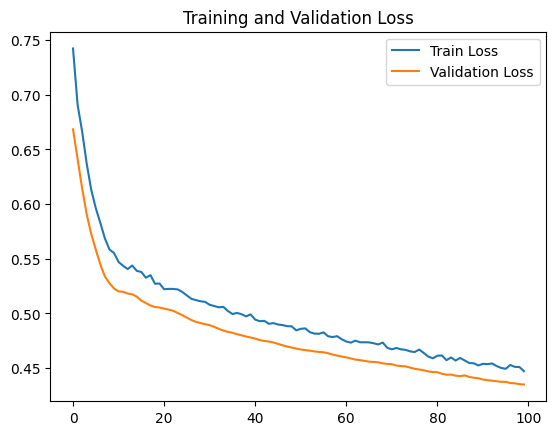

In [14]:
# ROZWIAZANIE
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

## **Zadanie 5:** Testowanie wytrenowanej sieci

### **Zadanie 5.1**

Wykorzystaj wytrenowaną sieć, żeby wykonać predykcje dla zbioru testowego. Zapisz wyniki również w formacie binarnym (np. [0,1,0,...,0]), żeby móc je łatwo porównać z prawdziwymi etykietami

In [15]:
# ROZWIAZANIE
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_probs = torch.sigmoid(test_outputs)
    preds = (test_probs > 0.5).float()


### **Zadanie 5.2**

Wyznacz tablicę pomyłek (confusion matrix). Możesz do tego użyć funkcji z `PyTorch` (link poniżej)

https://en.wikipedia.org/wiki/Confusion_matrix

https://lightning.ai/docs/torchmetrics/stable/classification/confusion_matrix.html

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

y_true = y_test_tensor.numpy()
y_pred = preds.numpy()

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[810 203]
 [178 696]]


Confusion matrix
- 0,0 : True negatives
- 0,1 : False positives
- 1,0 : False negatives
- 1,1 : True positives

### **Zadanie 5.3**

Wyznacz liczbę predykcji prawdziwie pozytywnych, prawdziwie negatywnych, fałszywie pozytywnych i fałszywie negatywnych (true positive, true negative, false positiv & false negative)

In [18]:
# ROZWIAZANIE
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")


TN: 810, FP: 203, FN: 178, TP: 696


### **Zadanie 5.4**

Wyznacz i wypisz następujące metryki opisujące skuteczność klasyfikatora binarnego:
- dokładność (accuracy)
- precyznja (precision)
- czułość (sensitivity)
- swoistość (specificity)

In [21]:
# ROZWIAZANIE
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
sensitivity = recall_score(y_true, y_pred)
specificity = tn / (tn + fp)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Accuracy: 0.7981
Precision: 0.7742
Sensitivity: 0.7963
Specificity: 0.7996


## **Zadanie 6: Modyfikacja sieci**

Wypróbuj różne liczby warstw i neuronów w poszczególnych warstwach. Spróbuj od nowa zdefiniować model i wytrenować sieć, albo użyć innych funkcji strat, bądź funkcji optymalizujących. Zobacz jak wpływają one na wygląd krzywych z zadań 4.5 i 4.6. Sprawdź jaka jest skuteczność predykcji na zbiorze testowym.

Używane urządzenie: cuda
Wczytywanie danych z cyp1a2.tab...
Znaleziono 12579 rekordów.
Przykładowe dane:
     Drug_ID                                               Drug  Y
0  6602638.0             CCCC(=O)Nc1ccc(N2CCN(CC)CC2)c(Cl)c1.Cl  0
1   644510.0  O=c1[nH]c2cc3c(cc2cc1CN(CCCO)Cc1nnnn1Cc1ccc(F)...  1

Konwersja SMILES na grafy (może to chwilę potrwać)...
Utworzono 12579 grafów. Wymiary wejścia: Node=39, Edge=6
Train: 8807, Val: 1886, Test: 1886

Rozpoczynanie treningu...
Epoch 05 | Train Loss: 0.4378 | Val Loss: 0.4366 | Val ACC: 0.8081 | Val AUC: 0.8879
Epoch 10 | Train Loss: 0.4137 | Val Loss: 0.4545 | Val ACC: 0.8054 | Val AUC: 0.8917
Epoch 15 | Train Loss: 0.3931 | Val Loss: 0.4395 | Val ACC: 0.8075 | Val AUC: 0.8962
Epoch 20 | Train Loss: 0.3763 | Val Loss: 0.4090 | Val ACC: 0.8256 | Val AUC: 0.9047
Epoch 25 | Train Loss: 0.3577 | Val Loss: 0.4324 | Val ACC: 0.8118 | Val AUC: 0.9088
Epoch 30 | Train Loss: 0.3544 | Val Loss: 0.4055 | Val ACC: 0.8250 | Val AUC: 0.9082


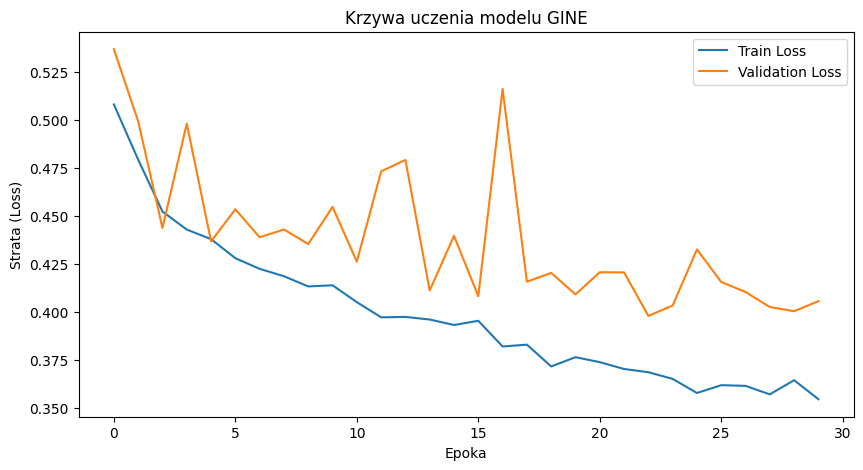


=== WYNIKI NA ZBIORZE TESTOWYM ===
Accuracy: 0.8478
AUC:      0.9178
Macierz pomyłek:
[[793 171]
 [116 806]]


In [25]:
# Importing dependecies

import os
try:
    import torch_geometric
    import rdkit
except ImportError:
    print("Instalowanie bibliotek...")
    import torch
    TORCH_VERSION = torch.__version__
    CUDA_VERSION = torch.version.cuda

    if CUDA_VERSION:
        version_suffix = f"torch-{TORCH_VERSION.split('+')[0]}+cu{CUDA_VERSION.replace('.', '')}"
    else:
        version_suffix = f"torch-{TORCH_VERSION.split('+')[0]}+cpu"

    pyg_whl_url = f"https://data.pyg.org/whl/{version_suffix}.html"

    !pip install -q rdkit
    !pip install -q torch-scatter torch-sparse torch-cluster -f {pyg_whl_url}
    !pip install -q torch-geometric

if not os.path.exists('cyp1a2.tab'):
    print("Pobieranie cyp1a2.tab...")
    !wget -q https://raw.githubusercontent.com/kugi8412/DockGraph/CYP1A2/SelectGINE/CYP1A2/data/cyp1a2.tab -O cyp1a2.tab

if not os.path.exists('prepare_data.csv'):
    print("Pobieranie prepare_data.csv...")
    !wget -q https://raw.githubusercontent.com/kugi8412/DockGraph/CYP1A2/SelectGINE/CYP1A2/data/prepare_data.csv -O prepare_data.csv


import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_add_pool
from rdkit import Chem
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

# Config
CONFIG = {
    'input_tab': 'cyp1a2.tab',
    'batch_size': 64,
    'epochs': 30,
    'learning_rate': 0.001,
    'hidden_dim': 128,
    'dropout': 0.3,
    'seed': 42,
    'val_split': 0.15,
    'test_split': 0.15
}

# Seed
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
random.seed(CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używane urządzenie: {DEVICE}")

PERMITTED_ATOMS = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'I', 'B', 'H']

# One hot
def one_hot_encoding(value, choices):
    encoding = [0] * (len(choices) + 1)
    index = choices.index(value) if value in choices else -1
    encoding[index] = 1
    return encoding

def get_atom_features(atom):
    features = one_hot_encoding(atom.GetSymbol(), PERMITTED_ATOMS)
    features += one_hot_encoding(atom.GetDegree(), [0, 1, 2, 3, 4])
    features += one_hot_encoding(atom.GetTotalNumHs(), [0, 1, 2, 3, 4])
    features += one_hot_encoding(atom.GetFormalCharge(), [-1, -2, 1, 2, 0])
    features += one_hot_encoding(str(atom.GetHybridization()), ['SP', 'SP2', 'SP3', 'SP3D', 'SP3D2'])
    features += [1 if atom.GetIsAromatic() else 0]
    features += [atom.GetMass() * 0.01]
    return features

def get_bond_features(bond):
    bt = bond.GetBondType()
    features = [
        1 if bt == Chem.rdchem.BondType.SINGLE else 0,
        1 if bt == Chem.rdchem.BondType.DOUBLE else 0,
        1 if bt == Chem.rdchem.BondType.TRIPLE else 0,
        1 if bt == Chem.rdchem.BondType.AROMATIC else 0,
    ]
    features += [1 if bond.GetIsConjugated() else 0]
    features += [1 if bond.IsInRing() else 0]
    return features

def smiles_to_graph_gine(smiles, label=None):
    """Konwertuje SMILES na obiekt Data PyTorch Geometric."""
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None

    # Atoms features
    atom_feats = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Edges anf features
    rows, cols, edge_feats = [], [], []
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        b_feat = get_bond_features(bond)
        rows += [start, end]; cols += [end, start]
        edge_feats += [b_feat, b_feat]

    if not rows:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, len(get_bond_features(Chem.MolFromSmiles("CC").GetBondWithIdx(0)))), dtype=torch.float)
    else:
        edge_index = torch.tensor([rows, cols], dtype=torch.long)
        edge_attr = torch.tensor(edge_feats, dtype=torch.float)

    y = torch.tensor([label], dtype=torch.float) if label is not None else None

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y, smiles=smiles)

# GINE Classifier ---
class GINEClassifier(nn.Module):
    def __init__(self, node_in, edge_in, hidden_dim, dropout=0.3):
        super(GINEClassifier, self).__init__()

        self.node_lin = nn.Linear(node_in, hidden_dim)
        self.edge_lin = nn.Linear(edge_in, hidden_dim)

        # GINEConv
        def make_gine_mlp():
            return nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )

        self.conv1 = GINEConv(make_gine_mlp())
        self.conv2 = GINEConv(make_gine_mlp())
        self.conv3 = GINEConv(make_gine_mlp())
        self.dropout = dropout
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = self.node_lin(x)
        if edge_attr.numel() > 0:
            edge_attr = self.edge_lin(edge_attr)
        else:
            edge_attr = torch.zeros((edge_index.size(1), x.size(1)), device=x.device)

        # Graph layers
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index, edge_attr)
        x = F.relu(x)

        # Global Pooling
        x = global_add_pool(x, batch)

        # MLP
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Input
print("Wczytywanie danych z cyp1a2.tab...")
try:
    df = pd.read_csv(CONFIG['input_tab'], sep='\t')
    print(f"Znaleziono {len(df)} rekordów.")
    print("Przykładowe dane:")
    print(df.head(2))
except Exception as e:
    print(f"Błąd wczytywania pliku: {e}")
    exit()

# To graph
graphs = []
print("\nKonwersja SMILES na grafy (może to chwilę potrwać)...")
dummy_mol = None
for idx, row in df.iterrows():
    g = smiles_to_graph_gine(row['Drug'], label=row['Y'])
    if g:
        graphs.append(g)
        if dummy_mol is None: dummy_mol = g

if not graphs:
    print("Błąd: Nie udało się utworzyć żadnego grafu.")
    exit()

node_dim = dummy_mol.x.shape[1]
edge_dim = dummy_mol.edge_attr.shape[1]
print(f"Utworzono {len(graphs)} grafów. Wymiary wejścia: Node={node_dim}, Edge={edge_dim}")

# Shuffle dataset
random.shuffle(graphs)
total = len(graphs)
n_val = int(total * CONFIG['val_split'])
n_test = int(total * CONFIG['test_split'])
n_train = total - n_val - n_test

train_data = graphs[:n_train]
val_data = graphs[n_train:n_train+n_val]
test_data = graphs[n_train+n_val:]

train_loader = DataLoader(train_data, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_data, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_data, batch_size=CONFIG['batch_size'], shuffle=False)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# Model
model = GINEClassifier(node_dim, edge_dim, CONFIG['hidden_dim'], CONFIG['dropout']).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
criterion = nn.BCEWithLogitsLoss()

# Training loop
train_losses, val_losses = [], []
print("\nRozpoczynanie treningu...")

for epoch in range(CONFIG['epochs']):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()

        out = model(batch)
        loss = criterion(out, batch.y.unsqueeze(1))

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    y_true, y_probs = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(DEVICE)
            out = model(batch)
            loss = criterion(out, batch.y.unsqueeze(1))
            val_loss += loss.item()

            probs = torch.sigmoid(out).cpu().numpy()
            y_probs.extend(probs)
            y_true.extend(batch.y.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)

    try:
        val_auc = roc_auc_score(y_true, y_probs)
        val_acc = accuracy_score(y_true, np.round(y_probs))
    except:
        val_auc = 0.0
        val_acc = 0.0

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val ACC: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Krzywa uczenia modelu GINE')
plt.xlabel('Epoka')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.show()

# Evaluation
model.eval()
test_true, test_probs = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        out = model(batch)
        probs = torch.sigmoid(out).cpu().numpy()
        test_probs.extend(probs)
        test_true.extend(batch.y.cpu().numpy())

test_preds = np.round(test_probs)
test_acc = accuracy_score(test_true, test_preds)
test_auc = roc_auc_score(test_true, test_probs)
cm = confusion_matrix(test_true, test_preds)

print("\n=== WYNIKI NA ZBIORZE TESTOWYM ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"AUC:      {test_auc:.4f}")
print("Macierz pomyłek:")
print(cm)
